This one is for running the simulation for Xgboost uncertainty 

In [30]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [31]:
# Path to your dataset
dataset_path = 'pybamm_b1.csv'
df_pm = pd.read_csv(dataset_path)

## Use a simple linear regression to predict sei firstly

In [32]:
features = ['slope1', 'crate']
target = ['sei_recd']

X = df_pm[features]
y = df_pm[target]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# normalize the data
from sklearn.preprocessing import StandardScaler
scalerx, scalery = StandardScaler(), StandardScaler()
X_train_scaled = scalerx.fit_transform(X_train)
X_test_scaled = scalerx.transform(X_test)
y_train_scaled = scalery.fit_transform(y_train)
y_test_scaled = scalery.transform(y_test)

<Axes: title={'center': 'Scatter Plot of Slope1 vs SEI Recorded'}, xlabel='slope1', ylabel='sei_recd'>

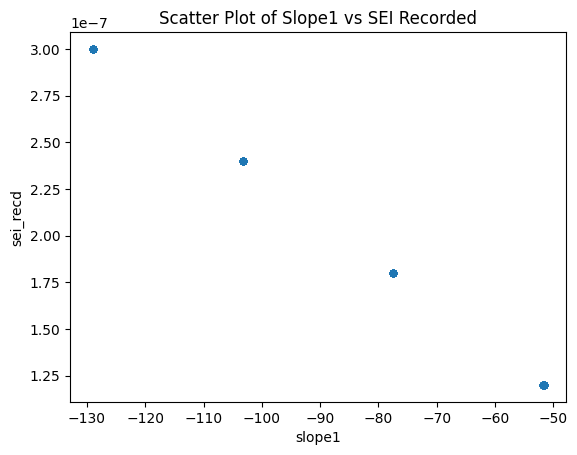

In [33]:
df_pm.plot(kind='scatter', x='slope1', y='sei_recd', title='Scatter Plot of Slope1 vs SEI Recorded')

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scalery.inverse_transform(y_pred_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)   
print("\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4e}")
print(f"R-squared (R²) Score: {r2:.4f}")


Model Evaluation:
Mean Squared Error (MSE): 4.8418e-21
R-squared (R²) Score: 1.0000


In [35]:
import pandas as pd

df = pd.read_csv('b1_c_rate.csv',index_col=0)

data_list = [
    (name, row["slopes1"]*1e6, row["slopes2"]*1e6, row["breaks2"],row["crate"],row["breaks3"])
    for name, row in df.iterrows()
]

for item in data_list[:5]:
    print(item)


('b1c1', -45.01540600951243, -175.4821534901, 1555.0, 3.6, 1935.0)
('b1c2', -46.58968593679797, -171.18914030899998, 1623.0, 3.6, 2106.0)
('b1c3', -43.388083657390254, -139.9472731426, 857.0, 4.0, 1109.0)
('b1c4', -43.30103875900308, -131.90551566050001, 1022.0, 4.0, 1399.0)
('b1c5', -60.52998736605819, -242.1673213538, 739.0, 4.4, 951.0)


In [36]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
sei = []
for key, value in enumerate(data_list):
    feature = [value[1], value[4]]
    feature_scaled = scalerx.transform([feature])
    sei_pred_scaled = model.predict(feature_scaled)
    sei_pred = scalery.inverse_transform(sei_pred_scaled.reshape(-1, 1))[0][0]
    sei.append([value[0], sei_pred])
print(sei[:5])

[['b1c1', 1.0426905562433314e-07], ['b1c2', 1.0793464603619486e-07], ['b1c3', 1.0054515410561424e-07], ['b1c4', 1.0034247671679708e-07], ['b1c5', 1.405239600241468e-07]]


In [37]:
# Define features (X) and target (y)
features = ['checkpoint','slope2','crate']
target = ['dead_lithium']

X = df_pm[features]
y = df_pm[target]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# normalize the data
from sklearn.preprocessing import StandardScaler
scalerx, scalery = StandardScaler(), StandardScaler()
X_train_scaled = scalerx.fit_transform(X_train)
X_test_scaled = scalerx.transform(X_test)
y_train_scaled = scalery.fit_transform(y_train)
y_test_scaled = scalery.transform(y_test)

<Axes: xlabel='slope2', ylabel='dead_lithium'>

<Figure size 1000x600 with 0 Axes>

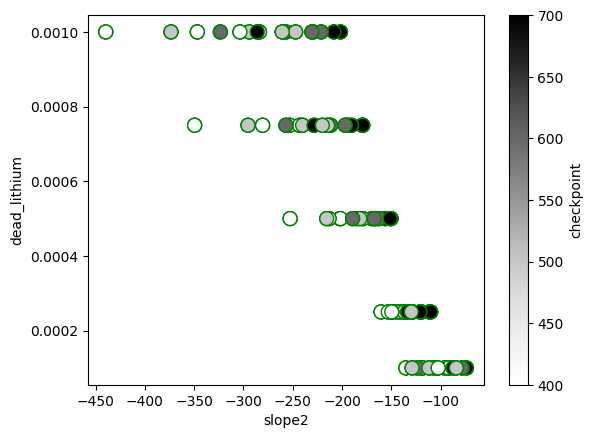

In [38]:
plt.figure(figsize=(10, 6))
df_pm.plot(kind='scatter', x = 'slope2', y ='dead_lithium', s=100, edgecolors = 'green', c ='checkpoint')

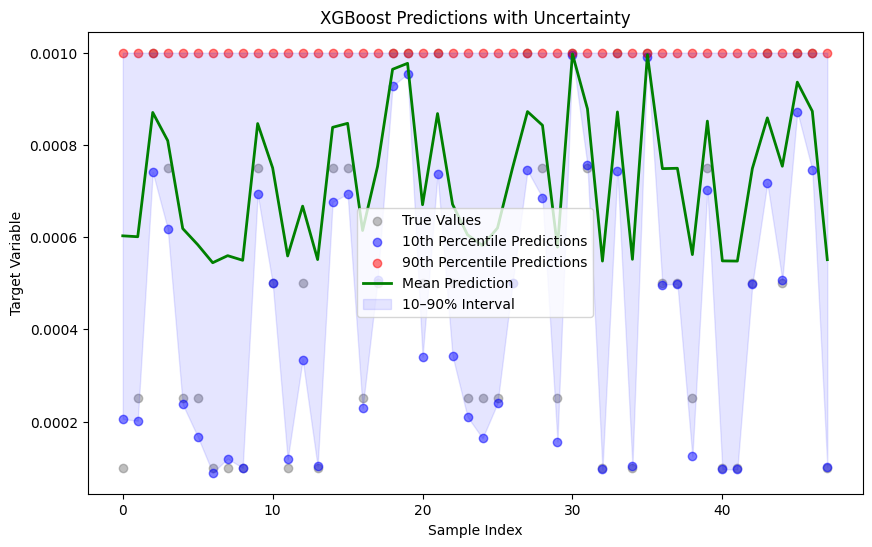

In [39]:
# Set the quantile levels
quantiles = [0.1, 0.9]  # Lower and upper bounds

models = {}
for q in quantiles:
    model = xgb.XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=q,
        n_estimators=3000,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='rmse')
    # Use scaled features for consistency with previous cells
    model.fit(X_train_scaled, y_train_scaled)
    models[q] = model

predictions = {}
for q in quantiles:
    preds = models[q].predict(X_test_scaled)
    # inverse back to real scale
    preds = scalery.inverse_transform(preds.reshape(-1,1)).ravel()
    predictions[q] = preds

mean_predictions = (predictions[0.1] + predictions[0.9]) / 2

plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='gray', label='True Values', alpha=0.5)
plt.scatter(range(len(y_test)), predictions[0.1], color='blue', label='10th Percentile Predictions', alpha=0.5)
plt.scatter(range(len(y_test)), predictions[0.9], color='red', label='90th Percentile Predictions', alpha=0.5)

# Point prediction
plt.plot(range(len(y_test)), mean_predictions, color='green', label='Mean Prediction', linewidth=2)

# Uncertainty band
plt.fill_between(
    range(len(y_test)), 
    predictions[0.1], 
    predictions[0.9], 
    color='blue', alpha=0.1, label='10–90% Interval'
)

plt.title('XGBoost Predictions with Uncertainty')
plt.xlabel('Sample Index')
plt.ylabel('Target Variable')
plt.legend()
plt.show()

In [40]:
import numpy as np

y_true = np.array(y_test).reshape(-1)
pred_low = np.array(predictions[0.1]).reshape(-1)
pred_high = np.array(predictions[0.9]).reshape(-1)

# Check how many true values fall within the prediction interval
covered = (y_true >= pred_low) & (y_true <= pred_high)

coverage_rate = covered.mean() * 100

print(f"There are {coverage_rate:.2f}% of true values within the prediction interval")

There are 79.17% of true values within the prediction interval


In [41]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

plating_lower = []
plating_upper = []

for value in data_list:
    feature = [value[3], value[2], value[4]]
    feature_scaled = scalerx.transform([feature])
    # print(feature)
    # prediction lower bound
    y_pred_scaled_l = models[0.1].predict(feature_scaled)
    y_pred_l = scalery.inverse_transform(y_pred_scaled_l.reshape(-1, 1))[0,0]

    # prediction upper bound
    y_pred_scaled_u = models[0.9].predict(feature_scaled)
    y_pred_u = scalery.inverse_transform(y_pred_scaled_u.reshape(-1, 1))[0,0]

    plating_lower.append([value[0], y_pred_l, value[3]])
    plating_upper.append([value[0], y_pred_u, value[3]])

print(plating_lower[:5])
print(plating_upper[:5])

[['b1c1', 0.0005085404, 1555.0], ['b1c2', 0.0005085404, 1623.0], ['b1c3', 0.00031977182, 857.0], ['b1c4', 0.00022873557, 1022.0], ['b1c5', 0.00096129987, 739.0]]
[['b1c1', 0.001, 1555.0], ['b1c2', 0.001, 1623.0], ['b1c3', 0.001, 857.0], ['b1c4', 0.001, 1022.0], ['b1c5', 0.001, 739.0]]


In [42]:
import pandas as pd

df_sei = pd.DataFrame(sei, columns=["id", "sei"])
df_plating_lower = pd.DataFrame(plating_lower, columns=["id", "plating", "b1"])
df_plating_upper = pd.DataFrame(plating_upper, columns=["id", "plating", "b1"])

df_combined_lower = pd.merge(df_sei, df_plating_lower, on="id")
df_combined_upper = pd.merge(df_sei, df_plating_upper, on="id")
print(df_combined_lower.head())
print(df_combined_upper.head())

     id           sei   plating      b1
0  b1c1  1.042691e-07  0.000509  1555.0
1  b1c2  1.079346e-07  0.000509  1623.0
2  b1c3  1.005452e-07  0.000320   857.0
3  b1c4  1.003425e-07  0.000229  1022.0
4  b1c5  1.405240e-07  0.000961   739.0
     id           sei  plating      b1
0  b1c1  1.042691e-07    0.001  1555.0
1  b1c2  1.079346e-07    0.001  1623.0
2  b1c3  1.005452e-07    0.001   857.0
3  b1c4  1.003425e-07    0.001  1022.0
4  b1c5  1.405240e-07    0.001   739.0


In [43]:
b2 = []
for key, value in enumerate(data_list):
    b2.append(value[5])
df_b2 = pd.DataFrame(b2)
df_b2.columns = ['b2']


In [44]:
crate = []
for key, value in enumerate(data_list):
    crate.append(value[4])
df_crate = pd.DataFrame(crate)
df_crate.columns = ['crate']

In [45]:
xg_pred_lower = pd.concat([df_combined_lower, df_b2,df_crate], axis=1)
print(xg_pred_lower.head())

     id           sei   plating      b1      b2  crate
0  b1c1  1.042691e-07  0.000509  1555.0  1935.0    3.6
1  b1c2  1.079346e-07  0.000509  1623.0  2106.0    3.6
2  b1c3  1.005452e-07  0.000320   857.0  1109.0    4.0
3  b1c4  1.003425e-07  0.000229  1022.0  1399.0    4.0
4  b1c5  1.405240e-07  0.000961   739.0   951.0    4.4


In [46]:
xg_pred_upper = pd.concat([df_combined_upper, df_b2,df_crate], axis=1)
print(xg_pred_upper.head())

     id           sei  plating      b1      b2  crate
0  b1c1  1.042691e-07    0.001  1555.0  1935.0    3.6
1  b1c2  1.079346e-07    0.001  1623.0  2106.0    3.6
2  b1c3  1.005452e-07    0.001   857.0  1109.0    4.0
3  b1c4  1.003425e-07    0.001  1022.0  1399.0    4.0
4  b1c5  1.405240e-07    0.001   739.0   951.0    4.4


In [47]:
# xg_pred_lower.to_csv('xgb_pred_lower.csv', index=False)
# xg_pred_upper.to_csv('xgb_pred_upper.csv', index=False)